手写求解变换

In [2]:
import numpy as np

def matvec(M, V):
    output = np.zeros(2)
    for i in range(2):
        output = output + V[i] * M[:,i]
    return output

M = np.array([[0,1.],[2,3.]])
V = np.array([2,-1.])
print(matvec(M,V))
print(M@V)

[-1.  1.]
[-1.  1.]


向量变换

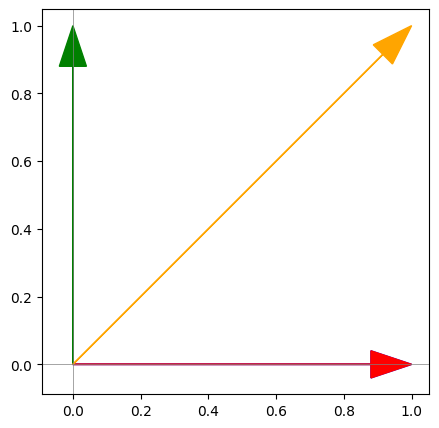

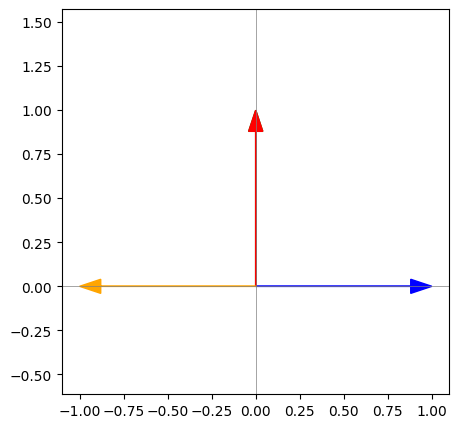

In [61]:
import matplotlib.pyplot as plt

def draw_vectors(vecs, colors):
      plt.figure(figsize=(5, 5))
      plt.axhline(0, color='gray', lw=0.5); plt.axvline(0, color='gray', lw=0.5)
      for (vec, c) in zip(vecs, colors):
          plt.arrow(0, 0, vec[0], vec[1], head_width=0.08, color=c, length_includes_head=True)
      plt.xlim(-3, 3); plt.ylim(-3, 3); plt.axis('equal')
      plt.show()

S = np.array([[1., 1.], [0., 1.]])   # 剪切：î 不动，ĵ 挪到 (1,1)
R = np.array([[0., -1.], [1., 0.]])  # 旋转 90°

  # 画出变换前的 î ĵ 和变换后的 S@î S@ĵ，两两对比
draw_vectors([ [1,0],[0,1], S@[1,0], S@[0,1] ], ['blue','green','red','orange'])
draw_vectors([ [1,0],[0,1], R@[1,0], R@[0,1] ], ['blue','green','red','orange'])


结合律计算

In [1]:
import numpy as np

v = np.array([1, 1.])

S = np.array([[1, 1.], [0, 1.]])
R = np.array([[0, -1.], [1, 0.]])

shear_then_rotate = R@(S@v)
rotate_then_shear = S@(R@v)
print('先剪切后旋转:', shear_then_rotate)
print('先旋转后剪切:', rotate_then_shear)
print('顺序改变结果:', not np.allclose(shear_then_rotate, rotate_then_shear))

same_order_diff_group = (R @ S) @ v == R @ (S @ v)   # 同一顺序，不同括号
print('分组不影响结果:', same_order_diff_group)

i_hat = np.array([1, 0.])
print((S@R) @ i_hat)
print((R@S) @ i_hat)

先剪切后旋转: [-1.  2.]
先旋转后剪切: [0. 1.]
顺序改变结果: True
分组不影响结果: [ True  True]
[1. 1.]
[0. 1.]


盲测

In [46]:
import numpy as np

i_hat = np.array([1, 0.])
j_hat = np.array([0, 1.])

a,b,c,d = 1,2,3,4
M = np.array([[a, b], [c, d]])

transformed_i_hat = M @ i_hat
transformed_j_hat = M @ j_hat
print(transformed_i_hat, transformed_j_hat)

#计算可知，若要到达(2,1)和(-1,3): a,c = 2,1 b,d=-1,3
a,b,c,d = 2,1,-1,3
M = np.array([[a, b], [c, d]])

output_i_hat = M @ i_hat
output_j_hat = M @ j_hat
print(output_i_hat, output_j_hat)




[1. 3.] [2. 4.]
[ 2. -1.] [1. 3.]
